<a href="https://colab.research.google.com/github/iarabertopena/active-learning-for-multi-label-streams/blob/main/notebooks/01_active_learning_multi_label_streams.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Bibliotecas

In [ ]:
%%writefile requirements.txt
numpy
pandas
scipy
matplotlib
seaborn
capymoa
psutil

Overwriting requirements.txt


In [ ]:
!pip install -r requirements.txt

### Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import psutil
import time
import os

from capymoa.classifier import (
    AdaptiveRandomForestClassifier,
    HoeffdingAdaptiveTree,
    StreamingRandomPatches
)

from capymoa.evaluation import prequential_evaluation

from capymoa.drift.detectors import ADWIN

from capymoa.stream import NumpyStream
from capymoa.stream import Schema

from IPython.utils import process
from collections import deque
from scipy.io import arff

from sklearn.metrics import (hamming_loss, f1_score)

### Datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/Flags.zip"

extract_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/flags"

with zipfile.ZipFile(base_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, "flags.arff")

print(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/flags/flags.arff


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/Emotions.zip"

extract_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/emotions"

with zipfile.ZipFile(base_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, "emotions.arff")

print(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/emotions/emotions.arff


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/Scene.zip"

extract_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/scene"

with zipfile.ZipFile(base_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, "scene.arff")

print(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/scene/scene.arff


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/SynHPGrad.arff"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/SynHPInc.arff"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/"

dataset_paths = {
    "flags": base_path + "flags/flags.arff",
    "emotions": base_path + "emotions/emotions.arff",
    "scene": base_path + "scene/scene.arff",
    #"synhpgrad": base_path + "SynHPGrad.arff",
    #"synhpinc": base_path + "SynHPInc.arff"
}

n_labels_dict = {
    "flags": 7,
    "emotions": 6,
    "scene": 6,
    #"synhpgrad": 8,
    #"synhpinc": 8
}

In [ ]:
def load_multilabel_dataset(dataset_name):

    dataset_path = dataset_paths[dataset_name]

    n_labels = n_labels_dict[dataset_name]

    # carregar arff
    data, meta = arff.loadarff(dataset_path)

    # dataframe
    df = pd.DataFrame(data)

    # converter bytes -> string/int
    for col in df.columns:

        if df[col].dtype == object:

            df[col] = df[col].apply(
                lambda x: x.decode('utf-8')
                if isinstance(x, bytes)
                else x
            )

    # converter tudo para float
    df = df.astype(float)

    # dataset sintéticos: labels no começo
    if dataset_name in ["synhpgrad", "synhpinc"]:

        Y = df.iloc[:, :n_labels].values.astype(int)

        X = df.iloc[:, n_labels:].values

    # datasets reais: labels no final
    else:

        X = df.iloc[:, :-n_labels].values

        Y = df.iloc[:, -n_labels:].values.astype(int)

    return X, Y

### Métricas de avaliação

In [ ]:
hamming_scores = []
exact_match_scores = []
f1_scores = []

### Binary Relevance

In [ ]:
class BinaryRelevance:

    def __init__(self, model_class, n_labels, schema):

        self.n_labels = n_labels
        self.models = []

        for _ in range(n_labels):

            model = model_class(
                schema=schema
            )

            self.models.append(model)

    # previsão
    def predict(self, x):

        predictions = []

        for model in self.models:

            temp_stream = NumpyStream(
                X=np.array([x]),
                y=np.array([0])
            )

            instance = temp_stream.next_instance()

            pred = model.predict(instance)

            if pred is None:
                pred = 0

            predictions.append(int(pred))

        return np.array(predictions)

    # probabilidades
    def predict_proba(self, x):

        probabilities = []

        for model in self.models:

            temp_stream = NumpyStream(
                X=np.array([x]),
                y=np.array([0])
            )

            instance = temp_stream.next_instance()

            proba = model.predict_proba(instance)

            if proba is None:
                proba = np.array([0.5, 0.5])

            probabilities.append(proba)

        return probabilities

    # treino
    def train(self, x, y, label_mask=None):

        # se não tem máscara, assume que todos os rótulos estão disponíveis
        if label_mask is None:
            label_mask = [True] * self.n_labels

        if len(label_mask) != self.n_labels:
            raise ValueError("label_mask deve ter tamanho n_labels")

        for j, model in enumerate(self.models):

            # treina apenas os rótulos observados
            if label_mask[j]:

              temp_stream = NumpyStream(
                  X=np.array([x]),
                  y=np.array([y[j]])
              )

              instance = temp_stream.next_instance()

              model.train(instance)

### Active Learning

In [ ]:
class ActiveLearningStrategy:

    def __init__(self):

        self.total_seen = 0
        self.total_queried = 0

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):
        raise NotImplementedError

#### Random

In [ ]:
class RandomSampling(ActiveLearningStrategy):

    def __init__(self, budget):

        super().__init__()

        self.budget = budget

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):

        self.total_seen += 1

        if np.random.rand() < self.budget:

            self.total_queried += 1

            return True

        return False

#### Uncertainty sampling

In [ ]:
def compute_uncertainty(probabilities):
    uncertainties = []

    for proba in probabilities:
        # Least Confidence
        confidence = np.max(proba)
        uncertainty = 1 - confidence
        uncertainties.append(uncertainty)

    result = np.max(uncertainties)

    return result

In [ ]:
class UncertaintySampling(ActiveLearningStrategy):

    def __init__(self, threshold):

        super().__init__()

        self.threshold = threshold

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):

        self.total_seen += 1

        uncertainty = compute_uncertainty(
            probabilities
        )

        if uncertainty >= self.threshold:

            self.total_queried += 1

            return True

        return False

#### Query-by-committee

In [ ]:
committee_models = [
    AdaptiveRandomForestClassifier,
    HoeffdingAdaptiveTree,
    StreamingRandomPatches
]

In [ ]:
class Committee:

    def __init__(self, model_classes, n_labels, schema):

        self.models = []

        for model_class in model_classes:

            br_model = BinaryRelevance(
                model_class=model_class,
                n_labels=n_labels,
                schema=schema
            )

            self.models.append(br_model)

    def predict_all(self, x):

        predictions = []

        for model in self.models:

            predictions.append(
                model.predict(x)
            )

        return np.array(predictions)

    def predict_proba_all(self, x):

        probabilities = []

        for model in self.models:

            probabilities.append(
                model.predict_proba(x)
            )

        return probabilities

    def train(self, x, y):

        for model in self.models:

            model.train(x, y)

In [ ]:
def compute_vote_entropy(predictions):

    entropies = []

    n_members = predictions.shape[0]

    for label in range(predictions.shape[1]):

        votes = predictions[:, label]

        counts = np.bincount(
            votes,
            minlength=2
        )

        probs = counts / n_members

        probs = probs[probs > 0]

        entropy = -np.sum(
            probs * np.log2(probs)
        )

        entropies.append(entropy)

    return np.mean(entropies)

In [ ]:
class QueryByCommittee(ActiveLearningStrategy):

    def __init__(self, threshold, warmup):

        super().__init__()

        self.threshold = threshold
        self.warmup = warmup

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):

        self.total_seen += 1

        # warm-up
        if self.total_seen <= self.warmup:

            self.total_queried += 1
            return True

        if committee_predictions is None:
            return False

        disagreement = compute_vote_entropy(committee_predictions)

        #print("disagreement_vote_entropy =", disagreement)

        if disagreement >= self.threshold:

            self.total_queried += 1

            return True

        return False

### Loop principal

In [ ]:
def run_experiment(dataset_name, strategy):

    print(f"Dataset: {dataset_name}")

    # carregar dados
    X, Y = load_multilabel_dataset(dataset_name)

    strategy.total_seen = 0
    strategy.total_queried = 0

    # schema
    dummy_X = np.zeros((1, X.shape[1]))
    dummy_y = np.zeros(1)

    stream = NumpyStream(
        X=dummy_X,
        y=dummy_y
    )

    schema = stream.get_schema()

    # modelo principal
    model = BinaryRelevance(
        model_class=AdaptiveRandomForestClassifier,
        n_labels=Y.shape[1],
        schema=schema
    )

    # detector de drift
    adwin = ADWIN()

    drift_points = []

    window_size = 100
    acc_window = []

    # comitê para QBC
    committee = Committee(
        model_classes=committee_models,
        n_labels=Y.shape[1],
        schema=schema
    )

    # tempo inicial
    start_time = time.time()

    # memória inicial
    process = psutil.Process(os.getpid())
    memory_before = process.memory_info().rss / 1024**2

    # métricas
    hamming_scores = []
    exact_match_scores = []
    f1_scores = []

    # loop prequential
    for i in range(len(X)):

        x = X[i]
        y = Y[i]

        # previsão do modelo principal
        y_pred = model.predict(x)

        # probabilidades do modelo principal
        probs = model.predict_proba(x)

        # previsões do comitê
        committee_predictions = committee.predict_all(x)

        # métricas
        ham = hamming_loss(y, y_pred)

        exact = int(
            np.array_equal(y, y_pred)
        )

        f1 = f1_score(
            y,
            y_pred,
            average="macro",
            zero_division=0
        )

        hamming_scores.append(ham)
        exact_match_scores.append(exact)
        f1_scores.append(f1)

        # detector
        adwin.add_element(ham)

        if adwin.detected_change():

            #print(f"Drift detectado em {i}")

            drift_points.append(i)

        # média móvel
        start = max(0, i - window_size)

        acc_window.append(
            np.mean(hamming_scores[start:i+1])
        )

        # Active Learning
        if strategy.query(
            x=x,
            y_pred=y_pred,
            probabilities=probs,
            committee_predictions=committee_predictions,
            committee_probabilities=None
        ):

            # treina modelo principal
            model.train(x, y)

            # treina todos os membros do comitê
            committee.train(x, y)

    # tempo final
    end_time = time.time()
    execution_time = end_time - start_time

    # memória final
    memory_after = process.memory_info().rss / 1024**2

    memory_usage = max(
        0,
        memory_after - memory_before
    )

    # consultas por segundo
    queries_per_second = (
        strategy.total_queried / execution_time
        if execution_time > 0
        else 0
    )

    # proporção de instâncias consultadas
    query_rate = (
        strategy.total_queried / strategy.total_seen
        if strategy.total_seen > 0
        else 0
    )

    # resultados finais
    results = {
      "Hamming Loss": np.mean(hamming_scores),
      "Exact Match": np.mean(exact_match_scores),
      "F1-score": np.mean(f1_scores),
      "Execution Time (s)": execution_time,
      "Memory Usage (MB)": memory_usage,
      "Queried Instances": strategy.total_queried,
      "Queries per Second": queries_per_second,
      "Query Rate": query_rate,
      "Drift Points": drift_points,
      "Number of Drifts": len(drift_points),
  }

    print(results)

    return results

In [ ]:
strategies = {
    "Random": RandomSampling(budget=0.10),
    "Uncertainty": UncertaintySampling(threshold=0.40),
    "QBC": QueryByCommittee(threshold=0.15, warmup=10)
}

for strategy_name, strategy in strategies.items():

    print(f"\nStrategy: {strategy_name}")

    results = run_experiment("flags", strategy)


Strategy: Random
Dataset: flags
{'Hamming Loss': np.float64(0.37702503681885124), 'Exact Match': np.float64(0.04639175257731959), 'F1-score': np.float64(0.5633176388331027), 'Execution Time (s)': 6.289161205291748, 'Memory Usage (MB)': 0.0625, 'Queried Instances': 11, 'Queries per Second': 1.7490408722143291, 'Query Rate': 0.05670103092783505, 'Drift Points': [], 'Number of Drifts': 0}

Strategy: Uncertainty
Dataset: flags
{'Hamming Loss': np.float64(0.304860088365243), 'Exact Match': np.float64(0.11855670103092783), 'F1-score': np.float64(0.6606757360623339), 'Execution Time (s)': 12.812684535980225, 'Memory Usage (MB)': 0.09375, 'Queried Instances': 92, 'Queries per Second': 7.180384387178827, 'Query Rate': 0.4742268041237113, 'Drift Points': [], 'Number of Drifts': 0}

Strategy: QBC
Dataset: flags
{'Hamming Loss': np.float64(0.31737849779086885), 'Exact Match': np.float64(0.07731958762886598), 'F1-score': np.float64(0.6602938441855969), 'Execution Time (s)': 8.566231727600098, 'Mem

### Rodando os 5 datasets

In [ ]:
all_results = {}

strategies = {
    "Random": RandomSampling(budget=0.10),
    "Uncertainty": UncertaintySampling(threshold=0.40),
    "QBC": QueryByCommittee(threshold=0.15, warmup=10)
}

for dataset_name in dataset_paths.keys():

    all_results[dataset_name] = {}

    for strategy_name, strategy in strategies.items():

        print(f"\nStrategy: {strategy_name}")

        results = run_experiment(
            dataset_name,
            strategy
        )

        all_results[dataset_name][strategy_name] = results


Strategy: Random
Dataset: flags
{'Hamming Loss': np.float64(0.321060382916053), 'Exact Match': np.float64(0.0979381443298969), 'F1-score': np.float64(0.6462710685648829), 'Execution Time (s)': 7.533157110214233, 'Memory Usage (MB)': 0.16796875, 'Queried Instances': 20, 'Queries per Second': 2.654929361938029, 'Query Rate': 0.10309278350515463, 'Drift Points': [], 'Number of Drifts': 0}

Strategy: Uncertainty
Dataset: flags
{'Hamming Loss': np.float64(0.304860088365243), 'Exact Match': np.float64(0.11855670103092783), 'F1-score': np.float64(0.6606757360623339), 'Execution Time (s)': 12.971167802810669, 'Memory Usage (MB)': 461.46484375, 'Queried Instances': 92, 'Queries per Second': 7.092653599012488, 'Query Rate': 0.4742268041237113, 'Drift Points': [], 'Number of Drifts': 0}

Strategy: QBC
Dataset: flags
{'Hamming Loss': np.float64(0.31737849779086885), 'Exact Match': np.float64(0.07731958762886598), 'F1-score': np.float64(0.6602938441855969), 'Execution Time (s)': 11.224961042404175

### Resultados

In [ ]:
rows = []

for dataset_name, strategies_results in all_results.items():

    for strategy_name, results in strategies_results.items():

        rows.append({
            "Dataset": dataset_name,
            "Strategy": strategy_name,
            "Hamming Loss": results["Hamming Loss"],
            "Exact Match": results["Exact Match"],
            "F1-score": results["F1-score"],
            "Execution Time (s)": results["Execution Time (s)"],
            "Memory Usage (MB)": results["Memory Usage (MB)"],
            "Queried Instances": results["Queried Instances"],
            "Queries per Second": results["Queries per Second"],
            "Query Rate": results["Query Rate"]

        })

df_results = pd.DataFrame(rows)

print(df_results)

    Dataset     Strategy  Hamming Loss  Exact Match  F1-score  \
0     flags       Random      0.363034     0.030928  0.585712   
1     flags  Uncertainty      0.304860     0.118557  0.660676   
2     flags          QBC      0.317378     0.077320  0.660294   
3  emotions       Random      0.289488     0.153457  0.610552   
4  emotions  Uncertainty      0.257448     0.160202  0.619137   
5  emotions          QBC      0.228218     0.204047  0.662761   
6     scene       Random      0.157319     0.304528  0.645094   
7     scene  Uncertainty      0.115704     0.530536  0.766686   
8     scene          QBC      0.286664     0.153303  0.497440   

   Execution Time (s)  Memory Usage (MB)  Queried Instances  \
0            5.800412         725.902344                 20   
1           12.265116           0.226562                 92   
2            8.777354           0.035156                 47   
3           38.807397         248.816406                 59   
4           82.105530         465.

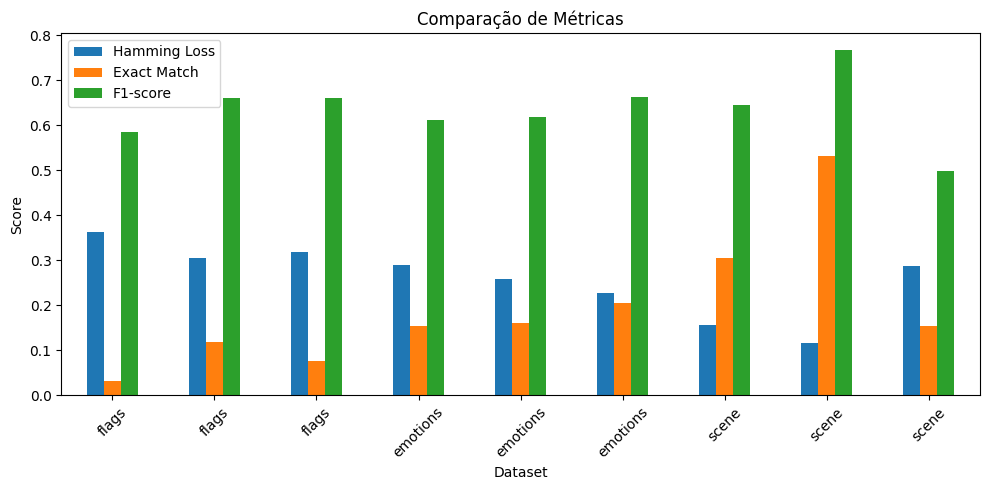

In [ ]:
metrics = [
    "Hamming Loss",
    "Exact Match",
    "F1-score"
]

df_results.plot(x="Dataset", y=metrics, kind="bar", figsize=(10,5)
)

plt.title("Comparação de Métricas")
plt.ylabel("Score")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Análise de drift com ADWIN

In [ ]:
for dataset_name, strategies_results in all_results.items():

    for strategy_name, results in strategies_results.items():

        print(f"\nStrategy: {strategy_name}")
        print(f"Dataset: {dataset_name} -> Drifts detectados:", results["Number of Drifts"])


Strategy: Random
Dataset: flags -> Drifts detectados: 0

Strategy: Uncertainty
Dataset: flags -> Drifts detectados: 0

Strategy: QBC
Dataset: flags -> Drifts detectados: 0

Strategy: Random
Dataset: emotions -> Drifts detectados: 0

Strategy: Uncertainty
Dataset: emotions -> Drifts detectados: 0

Strategy: QBC
Dataset: emotions -> Drifts detectados: 0

Strategy: Random
Dataset: scene -> Drifts detectados: 4

Strategy: Uncertainty
Dataset: scene -> Drifts detectados: 5

Strategy: QBC
Dataset: scene -> Drifts detectados: 6


### Análise de consumo de memória e tempo de execução

In [ ]:
rows = []

for dataset_name, strategies_results in all_results.items():

    for strategy_name, results in strategies_results.items():

        rows.append({
            "Dataset": dataset_name,
            "Strategy": strategy_name,
            "Execution Time (s)": results["Execution Time (s)"],
            "Memory Usage (MB)": results["Memory Usage (MB)"]
        })

df_results = pd.DataFrame(rows)

print(df_results)

    Dataset     Strategy  Execution Time (s)  Memory Usage (MB)
0     flags       Random            5.800412         725.902344
1     flags  Uncertainty           12.265116           0.226562
2     flags          QBC            8.777354           0.035156
3  emotions       Random           38.807397         248.816406
4  emotions  Uncertainty           82.105530         465.570312
5  emotions          QBC          116.273609         373.859375
6     scene       Random          394.204545           0.000000
7     scene  Uncertainty          474.831612        1641.691406
8     scene          QBC          263.957413           0.000000


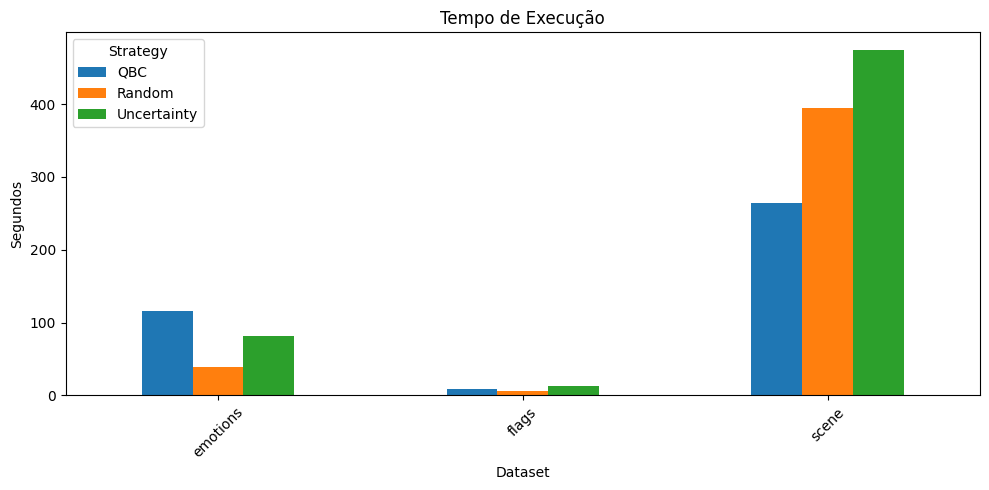

In [ ]:
pivot_time = df_results.pivot(
    index="Dataset",
    columns="Strategy",
    values="Execution Time (s)"
)

pivot_time.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Tempo de Execução")
plt.ylabel("Segundos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

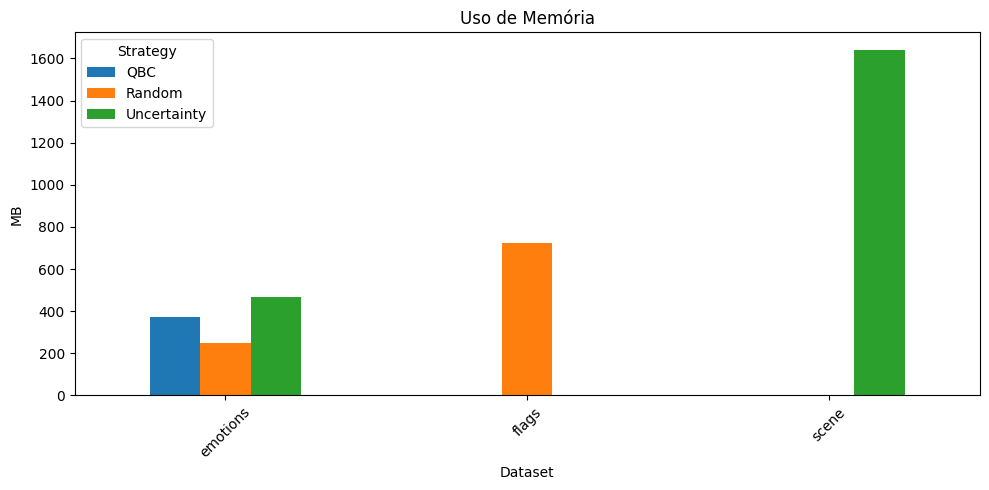

In [ ]:
pivot_memory = df_results.pivot(
    index="Dataset",
    columns="Strategy",
    values="Memory Usage (MB)"
)

pivot_memory.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Uso de Memória")
plt.ylabel("MB")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()